In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

df = pd.read_stata("../../data/HCMST 2017 to 2022 small public version 2.2.dta").copy()

/tmp/ipykernel_38522/1236531211.py:9: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  df = pd.read_stata("../../data/HCMST 2017 to 2022 small public version 2.2.dta").copy()


In [25]:
social_cols = [
    "w1_q24_met_through_friend",
    "w1_q24_met_through_family",
    "w1_q24_met_through_as_nghbrs"
]

work_cols = [
    "w1_q24_met_as_through_cowork",
    "w1_q24_customer",
    "w1_q24_work_neighbors",
    "w1_q24_business_trip"
]

internet_cols = [
    "w1_q24_internet_dating",
    "w1_q24_internet_soc_network",
    "w1_q24_internet_other"
]

all_binary_cols = social_cols + work_cols + internet_cols + ["w1_q24_met_online"]

for col in all_binary_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({"yes": 1, "no": 0})
    )

In [26]:
df["met_social"] = df[social_cols].sum(axis=1)
df["met_social"] = (df["met_social"] > 0).astype(int)

df["met_work"] = df[work_cols].sum(axis=1)
df["met_work"] = (df["met_work"] > 0).astype(int)

df["met_online"] = (
    df["w1_q24_met_online"]
    .fillna(0)
    .astype(int)
)

In [27]:
selected_cols = [
    "w1_ppage",
    "w1_age_when_met",
    "w1_partner_yrsed",
    "w1_married",
    "w1_partnership_status",
    "met_social",
    "met_work",
    "met_online"
]

df_cluster = df[selected_cols].dropna().copy()

In [28]:
df_cluster["w1_married"] = (
    df_cluster["w1_married"]
    .astype(str)
    .str.lower()
    .str.strip()
    .map({"yes": 1, "no": 0})
)

In [29]:
df_cluster = pd.get_dummies(
    df_cluster,
    columns=["w1_partnership_status"],
    drop_first=True
)

bool_cols = df_cluster.select_dtypes("bool").columns
df_cluster[bool_cols] = df_cluster[bool_cols].astype(int)

In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

kmeans = KMeans(n_clusters=2, random_state=42)
df_cluster["cluster"] = kmeans.fit_predict(X_scaled)

In [31]:
df_cluster.groupby("cluster").mean(numeric_only=True)

,w1_age_when_met,w1_partner_yrsed,w1_married,met_social,met_work,met_online,"w1_partnership_status_partnered, not married","w1_partnership_status_unpartnered, has had past partner",w1_partnership_status_never had a partner
cluster,,,,,,,,,
0,24.262798,14.305217,1.0,0.420283,0.260361,0.067284,0.000000,0.000000,0.0
1,30.427458,13.609984,0.0,0.322153,0.189548,0.202808,0.597504,0.402496,0.0


In [32]:
df_cluster.groupby("cluster")[["met_social", "met_work", "met_online"]].mean()

,met_social,met_work,met_online
cluster,,,
0,0.420283,0.260361,0.067284
1,0.322153,0.189548,0.202808


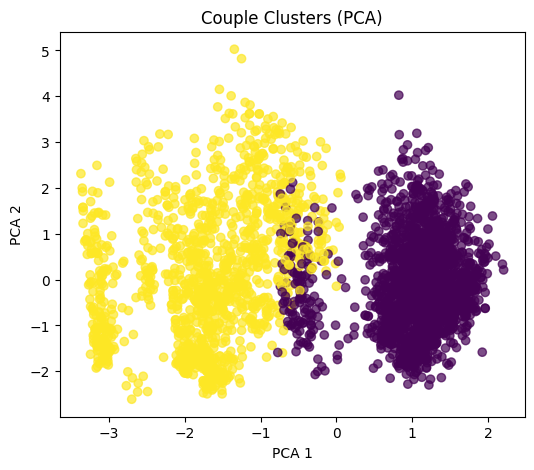

In [33]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_cluster["cluster"], alpha=0.7)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Couple Clusters (PCA)")
plt.show()

In [34]:
df["still_together"] = df["w3_breakup_source"].isna().astype(int)

df["cluster"] = np.nan
df.loc[df_cluster.index, "cluster"] = df_cluster["cluster"]

df.groupby("cluster")["still_together"].mean()

cluster
0.0    0.976597
1.0    0.953978
Name: still_together, dtype: float64

In [35]:
df_cluster.groupby("cluster")["w1_ppage"].mean()
df_cluster.groupby("cluster")["w1_age_when_met"].mean()

TypeError: category dtype does not support aggregation 'mean'